In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

In [2]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('S', 'P', 'D', 'F')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  


n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
    

In [12]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list_b(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, b_fields: np.ndarray, d, erange, angle
) -> list[pi.SystemPair]:
    
    basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

    basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))

    pair_systems = []
    for i, e in enumerate(b_fields):
        system1, system2 = pi.SystemAtom(basis1).set_electric_field([0,0,e], unit='V/cm'), pi.SystemAtom(basis2).set_electric_field([0,0,e], unit='V/cm')

        if i == 0:
            pair_energy = ket1.get_energy(unit=energy_unit) + ket2.get_energy(unit=energy_unit)

        pi.diagonalize([system1, system2])
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(d, unit='um', angle_degree=angle)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num


In [13]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  ...  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46  ...   
1     46     0   0.5    48     0   0.5    46     1   1.5    47  ...   
2     48     0   0.5    51     0   0.5    48     1   1.5    50  ...   
3     59     0   0.5    57     0   0.5    58     1   0.5    57  ...   
4     61     0   0.5    65     0   0.5    61     1   0.5    64  ...   
5     68     0   0.5    67     0   0.5    67     1   0.5    67  ...   
6     69     0   0.5    68     0   0.5    68     1   0.5    68  ...   
7     71     0   0.5    69     0   0.5    70     1   1.5    69  ...   
8     72     0   0.5    70     0   0.5    71     1   1.5    70  ...   
9     72     0   0.5    75     0   0.5    72     1   0.5    74  ...   
10    73     0   0.5    76     0   0.5    73     1   0.5    75  ...   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  ...   
12    81     0   0.5    78     0   0.5    80     1   0.5    78  ...   
13    

In [16]:
channel = 5
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1, mj2 = -j1_0, -j2_0
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
mj1_1, mj2_1 = j1_1, j2_1
f1_1, f2_1 = 1, 1

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']
minb = 0
maxb = .1
num=500
magnetic_fields = np.linspace(minb,maxb,num)
magnetic_fields_nums = enumerate(magnetic_fields)
nums_b_fields_sub = list(magnetic_fields_nums)[::2]
b_fields_sub = list(magnetic_fields)[::2]
r = [1500]
angle=0
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)

bfield = 0  # Gauss
erange = abs(defect + defect*6)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
print(system_pairs_dict)
for d in r:
    
    pairs = get_system_pair_list_b(ket1, ket2, b_fields_sub, d, erange, angle)
    system_pairs_dict[d] = pairs[0]
    states_num = pairs[1]
    print(system_pairs_dict[d])
    


print(system_pairs_dict)

{}
[SystemPair(BasisPair(|Rb:67,P_1/2,-1/2; Cs:67,P_3/2,-3/2⟩ ... |Rb:68,D_5/2,5/2; Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:67,P_1/2,-1/2; ~Cs:67,P_3/2,-1/2⟩ ... |~Rb:68,D_5/2,1/2; ~Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:67,P_1/2,-1/2; ~Cs:67,P_3/2,-1/2⟩ ... |~Rb:68,D_5/2,1/2; ~Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:67,P_1/2,-1/2; ~Cs:67,P_3/2,-1/2⟩ ... |~Rb:68,D_5/2,1/2; ~Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:67,P_1/2,-1/2; ~Cs:67,P_3/2,-1/2⟩ ... |~Rb:68,D_5/2,1/2; ~Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:67,P_1/2,-1/2; ~Cs:67,P_3/2,-1/2⟩ ... |~Rb:68,D_5/2,1/2; ~Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:67,P_1/2,-1/2; ~Cs:67,P_3/2,-1/2⟩ ... |~Rb:68,D_5/2,1/2; ~Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:67,P_1/2,-1/2; ~Cs:67,P_3/2,-1/2⟩ ... |~Rb:68,D_5/2,1/2; ~Cs:65,P_3/2,3/2⟩), is_diagonal=True), SystemPair(BasisPair(|~R

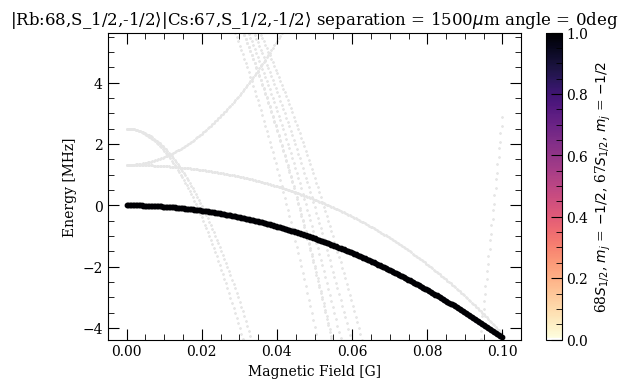

In [18]:


for i, d in enumerate(r):
    fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
    ax.set_xlabel("E_z (mV/cm)")
    ax.set_ylabel(f"Energy ({energy_unit})")
    ax.set_title(fr'separation {d} $\mu$m')
    # ax.set_ylim(-0.01, 0.01)

    # system_atom = system_atom_dict[efield]
    pair_energy = ket1_energy + ket2_energy
    system_pairs = system_pairs_dict[d]


    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in system_pairs]    
    overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]

    # ax.plot(e_fields_sub, energies)
    for x, es in zip(b_fields_sub, energies):
        plt.plot([x] * len(es), es, c='.9', ls="None", marker=".", ms=1, zorder=-1)

    # plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')

    plt.tight_layout()
    plt.title(fr'{str(ket1)}{str(ket2)} separation = {d}$\mu$m angle = {angle}deg')
    
    energy_lim = abs(defect + defect)
    offset=defect/4
    min_energy = -energy_lim+offset
    max_energy = energy_lim+offset
    plt.ylim(min_energy, max_energy)
    # plt.xlim(2, 2.7)
    plt.ylabel(f"Energy [{energy_unit}]")
    plt.xlabel("Magnetic Field [G]")

    min_overlap = 0.0001
    for x, es, os in zip(b_fields_sub, energies, overlaps):
        inds = np.argwhere(os > min_overlap).flatten()
        inds = inds[np.argsort(os[inds])]
        if len(inds) > 0:
            scat = plt.scatter(
                [x] * len(es[inds]),
                es[inds],
                c=os[inds],
                s=10,
                vmin=0,
                vmax=1,
                cmap=alphamagma,
            )
    fig.colorbar(scat, ax=ax, label=fr"{ket1.n}${orbs[int(ket1.l)]}_{{{int(ket1.j*2)}/2}}$, $m_j$ = ${int(ket1.m*2)}/2$, {ket2.n}${orbs[int(ket2.l)]}_{{{int(ket2.j*2)}/2}}$, $m_j$ = ${int(ket2.m*2)}/2$")
    # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
    plt.show()
    import os
    figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\Magnetic Plots\\overlapped\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\'
    if not os.path.exists(figpath):
        os.makedirs(figpath)
    fig.savefig(figpath + f'level pairstate sep{r} deg{angle}.png')